                                            STUDY HABITS ANALYSIS📊
### Pyhton & Statistics Data Analysis Project
-This project analyzes my study habits using Python,Pandas,Matplotlib,Seaborn and Statistics

## INTRODUCTION
This project analyzes my daily study habits using Python and Statistics.The analysis focuses on study hours,
focus time,study timing,subjects,and study-day patterns to identify meaningful trends and insights.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt 
import seaborn as sns 

In [2]:
df=pd.read_csv("study_data (1).csv")
df

,Date,Total_study_hours,Max_focus_hours,Start time,End time,Subject,Day off
0,9/1/2026,NaN,NaN,NaN,NaN,NaN,Yes
1,9/2/2026,NaN,NaN,NaN,NaN,NaN,Yes
2,9/3/2026,6.0,3.5,12PM,10PM,Python,No
3,9/4/2026,10.0,4.5,1PM,5AM,Python,No
4,9/5/2026,6.5,2.0,7AM,5PM,Python,No
5,9/6/2026,NaN,NaN,NaN,NaN,NaN,Yes
6,9/7/2026,12.5,4.5,9AM,5AM,Stats,No
7,9/8/2026,3.0,2.0,2PM,6PM,Stats,No
8,9/9/2026,4.0,3.5,2PM,6PM,Python,No
9,9/10/2026,1.0,1.0,4PM,5PM,Python,No


In [75]:
df.head()

,Date,Total_study_hours,Max_focus_hours,Start time,End time,Subject,Day off
0,9/1/2026,NaN,NaN,NaN,NaN,NaN,Yes
1,9/2/2026,NaN,NaN,NaN,NaN,NaN,Yes
2,9/3/2026,6.0,3.5,12.0,10PM,Python,No
3,9/4/2026,10.0,4.5,13.0,5AM,Python,No
4,9/5/2026,6.5,2.0,7.0,5PM,Python,No


In [76]:
df.tail()

,Date,Total_study_hours,Max_focus_hours,Start time,End time,Subject,Day off
25,9/26/2026,NaN,NaN,NaN,NaN,NaN,Yes
26,9/27/2026,NaN,NaN,NaN,NaN,NaN,Yes
27,9/28/2026,NaN,NaN,NaN,NaN,NaN,Yes
28,9/29/2026,NaN,NaN,NaN,NaN,NaN,Yes
29,9/30/2026,NaN,NaN,NaN,NaN,NaN,NaN


In [77]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 30 entries, 0 to 29
Data columns (total 7 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Date               30 non-null     str    
 1   Total_study_hours  21 non-null     float64
 2   Max_focus_hours    21 non-null     float64
 3   Start time         21 non-null     float64
 4   End time           21 non-null     str    
 5   Subject            21 non-null     str    
 6   Day off            29 non-null     str    
dtypes: float64(3), str(4)
memory usage: 1.8 KB


In [78]:
df.describe()

,Total_study_hours,Max_focus_hours,Start time
count,21.000000,21.000000,21.000000
mean,6.952381,4.138095,11.285714
std,3.032758,2.087696,2.452404
min,1.000000,1.000000,7.000000
25%,5.000000,3.000000,9.000000
50%,6.000000,3.500000,11.000000
75%,9.000000,4.500000,13.000000
max,12.500000,10.000000,16.000000


In [79]:
df.isnull().sum()

Date                 0
Total_study_hours    9
Max_focus_hours      9
Start time           9
End time             9
Subject              9
Day off              1
dtype: int64

In [80]:
df['Day off'].value_counts(dropna=False)

Day off
No     21
Yes     8
NaN     1
Name: count, dtype: int64

In [71]:
df['Subject']=df['Subject'].str.strip()

In [72]:
df['Subject'].unique()

<StringArray>
[nan, 'Python', 'Stats']
Length: 3, dtype: str

In [65]:
## Data Preprocessing: Converting Start Time to Hours
# The Start time column was stored as text (e.g., 9:30 AM), so it is converted into numeric hours (e.g., 9.5) to include it in the correlation analysis.
df=pd.read_csv('study_data (1).csv')
t=pd.to_datetime(df['Start time'],errors='coerce') 
df['Start time']=t.dt.hour + t.dt.minute / 60

C:\Users\bastt\AppData\Local\Temp\ipykernel_6212\623488533.py:4: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  t=pd.to_datetime(df['Start time'],errors='coerce')


                                                   ## MATPLOTLIB VISUALIZATIONS 

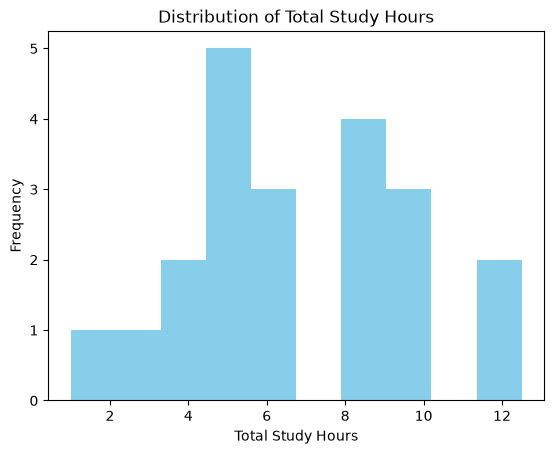

In [66]:
plt.hist(df['Total_study_hours'],color='skyblue')
plt.xlabel('Total Study Hours')
plt.ylabel('Frequency')
plt.title('Distribution of Total Study Hours')
plt.show()

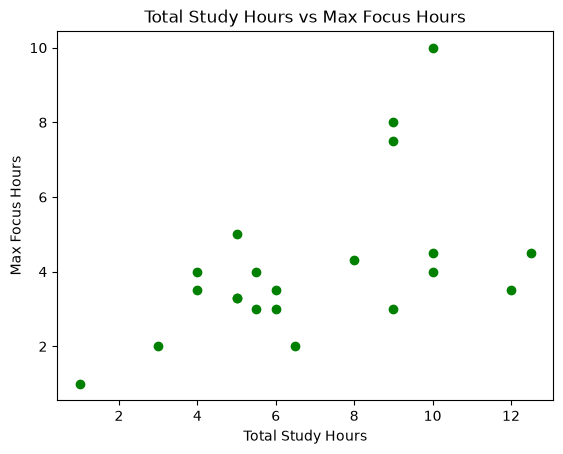

In [67]:
plt.scatter(df['Total_study_hours'], df['Max_focus_hours'], color='green')

plt.xlabel('Total Study Hours')
plt.ylabel('Max Focus Hours')
plt.title('Total Study Hours vs Max Focus Hours')

plt.show()


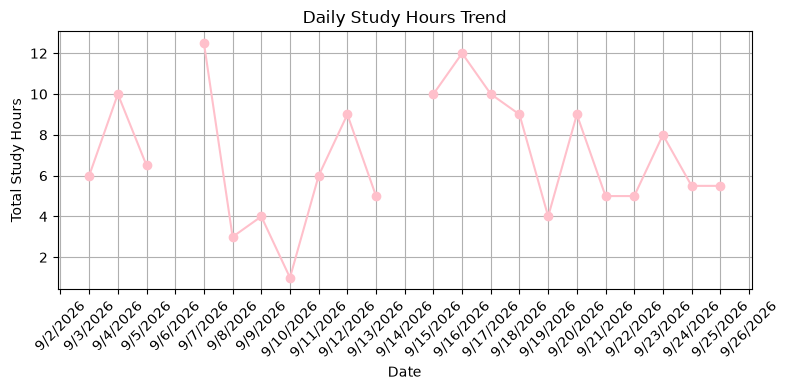

In [68]:
# Daily study hours trend
plt.figure(figsize=(8,4))
plt.plot(df['Date'], df['Total_study_hours'], marker='o', color='pink')

plt.xlabel('Date')
plt.ylabel('Total Study Hours')
plt.title('Daily Study Hours Trend')

plt.xticks(rotation=45)
plt.grid(True)
plt.tight_layout()
plt.show()

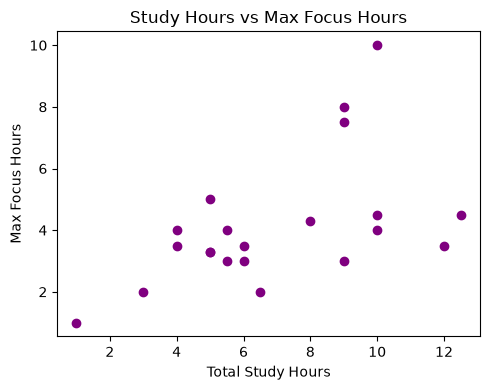

In [69]:
#Study hours vs Max focus 
plt.figure(figsize=(5,4))

plt.scatter(df['Total_study_hours'], df['Max_focus_hours'], color='purple')

plt.xlabel('Total Study Hours')
plt.ylabel('Max Focus Hours')
plt.title('Study Hours vs Max Focus Hours')

plt.tight_layout()
plt.show()

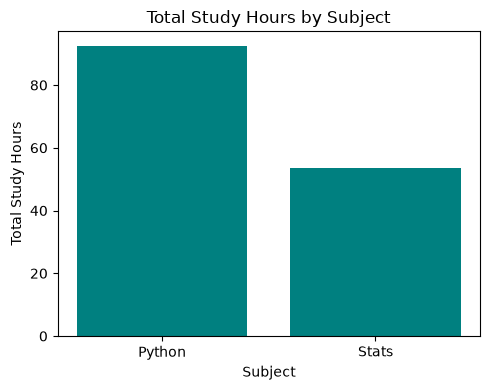

In [73]:
#Study hours by subject 
subject_hours = df.groupby('Subject')['Total_study_hours'].sum()

plt.figure(figsize=(5,4))
plt.bar(subject_hours.index, subject_hours.values, color='teal')

plt.xlabel('Subject')
plt.ylabel('Total Study Hours')
plt.title('Total Study Hours by Subject')

plt.tight_layout()
plt.show()

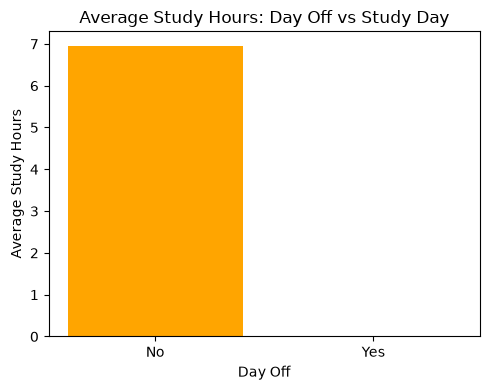

In [83]:
#Study hours: Day off vs study day 
day_hours = df['Total_study_hours'].fillna(0).groupby(df['Day off']).mean()

plt.figure(figsize=(5,4))
plt.bar(day_hours.index, day_hours.values, color='orange')

plt.xlabel('Day Off')
plt.ylabel('Average Study Hours')
plt.title('Average Study Hours: Day Off vs Study Day')

plt.tight_layout()
plt.show()

### Observation: Day Off vs Study Day
Average study hours on regular study days are about 6.95 hours.
No study hours were recorded for day-off entries,so a comparison between the two is not possible.

                                                       ## SEABORN VISUALIZATIONS

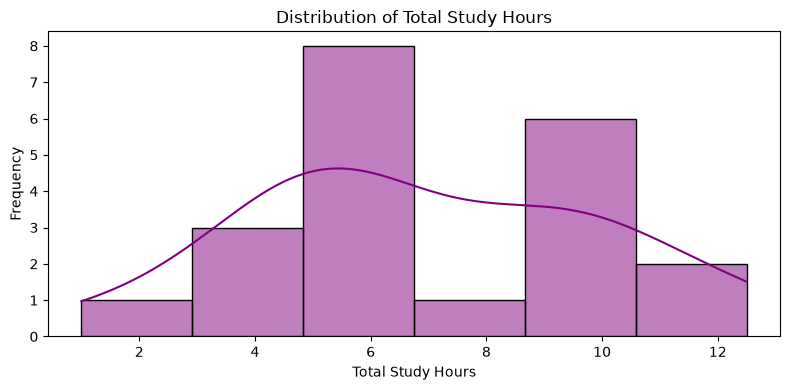

In [36]:
# Study hours distribution 
plt.figure(figsize=(8,4))

sns.histplot(df['Total_study_hours'], kde=True, color='purple')

plt.xlabel('Total Study Hours')
plt.ylabel('Frequency')
plt.title('Distribution of Total Study Hours')

plt.tight_layout()
plt.show()

In [44]:
# NaN values are kept because no study time was recorded on those days 
df['Study_hour']=df['Start time'].str.extract(r'(\d+)')[0].astype(float)
df.loc[df['Start time'].str.contains('PM',na=False) & (df['Study_hour']!=12),'Study_hour']+=12

In [46]:
df[['Start time','Study_hour']].dropna()

,Start time,Study_hour
2,12PM,12.0
3,1PM,13.0
4,7AM,7.0
6,9AM,9.0
7,2PM,14.0
8,2PM,14.0
9,4PM,16.0
10,10AM,10.0
11,2PM,14.0
12,11AM,11.0


In [ ]:
##  CORRELATION ANALYSIS
# Examining relationships between Study hours ,Focus hours and Start time
- This heatmap shows the strength & direction of relationships between key study variables

In [84]:
# Loading Data and Converting Start Time to Hours 
df=pd.read_csv('study_data (1).csv')
t=pd.to_datetime(df['Start time'],errors='coerce') 
df['Start time']=t.dt.hour + t.dt.minute / 60

C:\Users\bastt\AppData\Local\Temp\ipykernel_6212\394440478.py:3: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  t=pd.to_datetime(df['Start time'],errors='coerce')


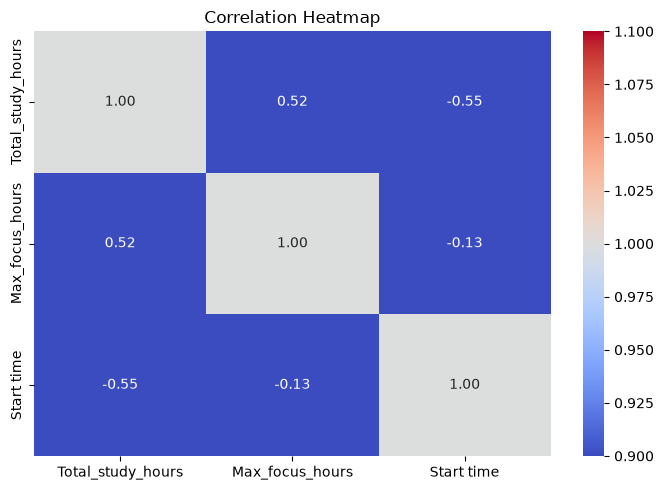

In [85]:
plt.figure(figsize=(7,5))
sns.heatmap(
    df[['Total_study_hours', 'Max_focus_hours', 'Start time']].corr(),
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    vmin=1,
    vmax=1
)
plt.title('Correlation Heatmap')
plt.tight_layout()
plt.show()

### Insights: Correlation Analysis

- **Study hours and focus (0.52):** Total study hours show a moderate positive correlation with max focus hours, suggesting that students who study longer also tend to sustain longer focus sessions.
- **Start time and study hours (-0.55):** Start time has a moderate negative correlation with total study hours. Earlier start times are generally associated with longer study sessions.
- **Start time and focus (-0.13):** The relationship between start time and max focus hours is very weak, so when a student starts has little link to how long they stay focused.

**Conclusion:** Studying longer and starting earlier go together, while focus duration is largely independent of start time. These are associations, not proof of cause and effect.


# KEY STATISTICAL INSIGHTS 
- This section summarizes the key patterns observed in the study data using descriptive statistics.

In [86]:
df[['Total_study_hours',
    'Max_focus_hours']].describe()

,Total_study_hours,Max_focus_hours
count,21.000000,21.000000
mean,6.952381,4.138095
std,3.032758,2.087696
min,1.000000,1.000000
25%,5.000000,3.000000
50%,6.000000,3.500000
75%,9.000000,4.500000
max,12.500000,10.000000


### Insights: Descriptive Statistics
- **Total study hours:** On average, students studied about 6.95 hours (median 6), with a range of 1 to 12.5 hours. The standard deviation of about 3.03 shows a wide spread in study habits.
- **Max focus hours:** The average longest focus session is about 4.14 hours (median 3.5), ranging from 1 to 10 hours.
- **Comparison:** Study hours vary more than focus hours, and the average study time is higher than the average focus time, which suggests students take breaks within their study sessions.


                                              # Subject-Wise Study Analysis
-this section compares study-time & focus across different subject.

## Data Cleaning: Standardizing Subject Names
-Subject names had inconsistent formatting (extra spaces or different capitalization), which created duplicate groups.They are standardized before the subject-wise analysis.

In [93]:
df['Subject'] = df['Subject'].str.strip().str.title()

In [94]:
Subject_analysis = df.groupby("Subject").agg(
    Avg_study_hours=('Total_study_hours', 'mean'),
    Total_study_hours=('Total_study_hours', 'sum'),
    Avg_focus_hours=('Max_focus_hours', 'mean'),
    Total_focus_hours=('Max_focus_hours', 'sum')
).round(2)
Subject_analysis

,Avg_study_hours,Total_study_hours,Avg_focus_hours,Total_focus_hours
Subject,,,,
Python,7.12,92.5,4.12,53.5
Stats,6.69,53.5,4.18,33.4


<h1 style="text-align:center;">KEY FINDINGS</h1>

The analysis of the study data revealed several important patterns:

- Average daily study time was 6.95 hours, while average maximum focus time was 4.14 hours.
- Study hours and maximum focus showed a moderate positive correlation (0.52).
- Earlier study start times were generally associated with longer study sessions, with a correlation of -0.55.
- Study time ranged from 1 to 12.5 hours, showing variation across different study days.


<h1 style="text-align:center;">CONCLUSION</h1>


This project analyzed my study habits using Python and Statistics. The analysis helped identify patterns in study duration, focus time, study timing, subject-wise study hours, and study-day patterns. Overall, the project demonstrates how data analysis can be used to understand study behavior and derive meaningful insights from everyday data.

